In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import helpers
path = os.getcwd()
train_path = path + r"\data\train.parquet"
test_path = path + r"\data\test.parquet"
sensors_path = path + r"\data\sensors.parquet"


train = pd.read_parquet(train_path)
test = pd.read_parquet(test_path)
sensors = pd.read_parquet(sensors_path)

In [25]:
train = train.copy()

In [24]:
train.sample(10)

,sensor,time,power,temperature
3446316,N629,4.371408e+09,500.000000,24.896170
3050200,N436,1.251158e+09,1000.000000,15.086678
961841,N510,2.937859e+09,530.960449,25.543287
2023741,N905,5.574269e+09,362.257904,30.071241
4031433,N853,5.169830e+09,0.000000,16.405905
2133527,N921,5.790269e+09,354.594543,19.595242
3316310,N577,2.458339e+09,1500.000000,33.903240
2204641,N96,4.140720e+09,429.954132,16.369930
3499004,N646,2.574115e+09,1500.000000,37.557888
5845229,N697,2.858371e+09,1400.000000,33.912743


In [32]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 6626928 entries, 0 to 6626927
Columns: 245 entries, time to sensor_N96
dtypes: bool(242), float32(2), float64(1)
memory usage: 1.6 GB


In [8]:
train.describe(include="all")

,sensor,time,power,temperature
count,6626928,6.626928e+06,6.626928e+06,6.527525e+06
unique,242,NaN,NaN,NaN
top,N102,NaN,NaN,NaN
freq,27384,NaN,NaN,NaN
mean,NaN,3.942130e+09,5.549463e+02,4.706070e+01
std,NaN,2.275997e+09,5.258427e+02,3.897674e+02
min,NaN,0.000000e+00,0.000000e+00,-2.921508e+02
25%,NaN,1.971605e+09,0.000000e+00,1.566275e+01
50%,NaN,3.942432e+09,4.445813e+02,1.939439e+01
75%,NaN,5.913173e+09,1.000000e+03,2.877052e+01


In [27]:
train.isna().any()

sensor         False
time           False
power          False
temperature     True
dtype: bool

In [ ]:
#selection des sensor proches

In [28]:
train["temperature"] = train["temperature"].fillna(train["temperature"].mean()) #ici à la place de prendre le mean de tout, il faudrait prendre celui des 3-4 sensor les plus proches --> KNN

In [29]:
train.isna().any() #control qu'on ai bien rempli toutes les missing values

sensor         False
time           False
power          False
temperature    False
dtype: bool

In [30]:
train = pd.get_dummies(train) #one-hot-encoding

In [13]:
train.sample(10)

,time,power,temperature,sensor_N102,sensor_N103,sensor_N108,sensor_N112,sensor_N113,sensor_N12,sensor_N121,...,sensor_N920,sensor_N921,sensor_N922,sensor_N923,sensor_N924,sensor_N925,sensor_N926,sensor_N927,sensor_N928,sensor_N96
5776835,6.857395e+09,0.000000,14.682570,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6588718,6.417619e+09,0.000000,3.318462,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
394759,1.948493e+09,680.586548,27.497004,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4420609,2.295821e+09,1400.000000,18.188234,True,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3491100,3.631738e+09,1000.000000,35.037251,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2154626,3.611520e+08,1242.922363,59.409592,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
3116946,3.712954e+09,1000.000000,24.864830,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5798362,1.799021e+09,1400.000000,30.244768,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
6516549,7.156426e+09,0.000000,3.961493,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
5573695,4.850150e+09,0.000000,12.895988,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False


<Axes: xlabel='coor_x', ylabel='coor_y'>

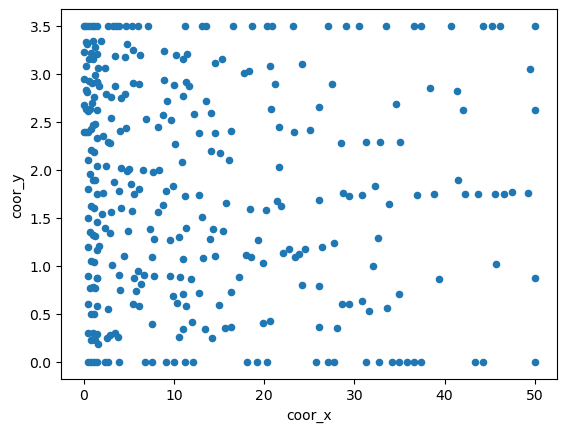

In [2]:
sensors.plot(kind='scatter', x='coor_x', y='coor_y')

<Axes: xlabel='time', ylabel='power'>

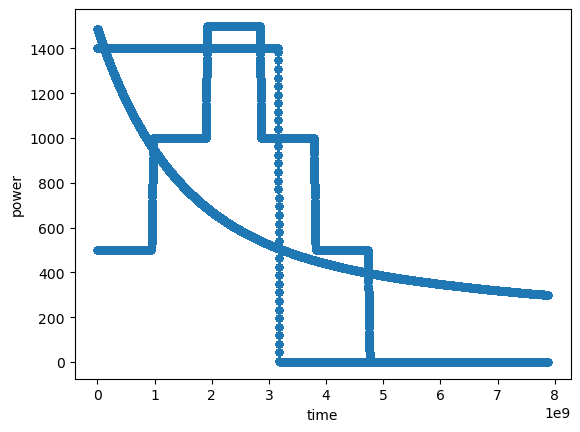

In [9]:
train.plot(kind='scatter', x='time', y='power')

<Axes: xlabel='time', ylabel='power'>

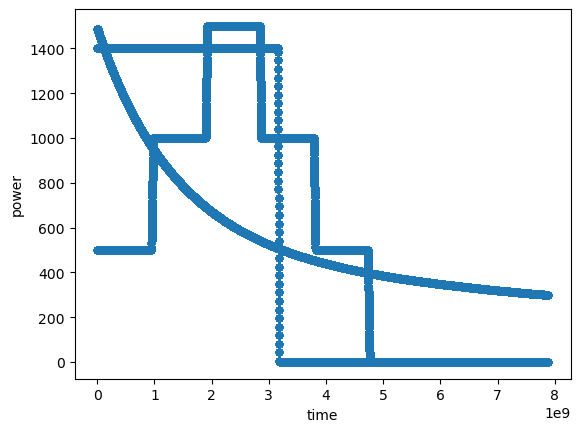

In [10]:
test.plot(kind='scatter', x='time', y='power')

<Axes: xlabel='time', ylabel='temperature'>

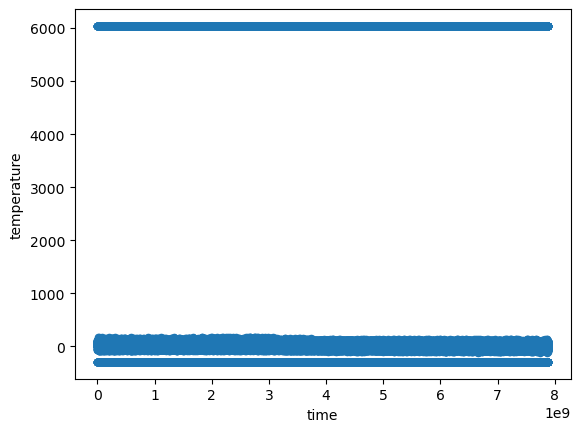

In [11]:
train.plot(kind='scatter', x='time', y='temperature')

<Axes: xlabel='sensor', ylabel='temperature'>

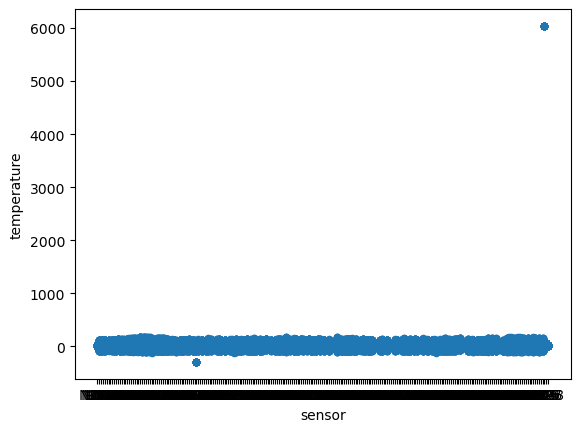

In [13]:
train.plot(kind='scatter', x='sensor', y='temperature')